# NORESTE 2
# PM 2.5 and PM 10 Analysis
A test of model performance to analyze the time series behaviour of particulate matter.

## Placing of directory


In [1]:
import os
from pathlib import Path
print("Directorio actual:", os.getcwd())

current_dir = Path.cwd()
project_root = current_dir
while not (project_root / '.git').exists() and project_root != project_root.parent:
    project_root = project_root.parent
    os.chdir("..")

print(f"Raíz del proyecto: {project_root}")
print("CWD cambiado a raíz del proyecto")

Directorio actual: /home/ferrus/Documents/university/semester_x/MA2003B/PROYECTO_MA2003B/notebooks/03_models
Raíz del proyecto: /home/ferrus/Documents/university/semester_x/MA2003B/PROYECTO_MA2003B
CWD cambiado a raíz del proyecto


## Library imports and mastertable

In [108]:
import pandas as pd
import numpy as np
import src.data_prep.table_generator as tables_gen
from src.data_prep import imputation
from src.data_prep import smoothing
import src.data_prep.time_series_visual as visual_ts
import warnings
import matplotlib

matplotlib.set_loglevel("ERROR")  # Solo muestra errores, no warnings

warnings.filterwarnings("ignore") 
path_master = "data/processed/master_table.csv"
df_master   = pd.read_csv(path_master)

## PM 2.5 and PM 10 tables

Table generation for pm2.5 and pm10 measures on station **noreste2**.

In [3]:
df_table_pm25 = tables_gen.orchestrate_contaminant_station_table(df_master, "pm2.5", "noreste2")
df_table_pm10 = tables_gen.orchestrate_contaminant_station_table(df_master, "pm10", "noreste2")

In [4]:
df_table_pm25.head()

,hour_of_year,pm2.5_2022,pm2.5_2023,pm2.5_2024
0,1,137.0,67.0,351.0
1,2,113.0,101.0,351.0
2,3,141.0,143.0,331.0
3,4,168.0,154.0,286.0
4,5,139.0,166.0,178.0


In [5]:
df_table_pm10.head()

,hour_of_year,pm10_2022,pm10_2023,pm10_2024
0,1,182.0,93.0,484.0
1,2,166.0,162.0,484.0
2,3,184.0,209.0,429.0
3,4,201.0,220.0,426.0
4,5,216.0,219.0,262.0


## Generación de intervalos de confianza PM2.5 2022, 2023, 2024.

## Time series filtering

In [19]:
df_pm25_2022 = df_table_pm25[['hour_of_year', "pm2.5_2022"]]
df_pm25_2023 = df_table_pm25[['hour_of_year', "pm2.5_2023"]]
df_pm25_2024 = df_table_pm25[['hour_of_year', "pm2.5_2024"]]



imputer_pm25_2022 = imputation.TimeSeriesImputer(df_pm25_2022)
imputer_pm25_2023 = imputation.TimeSeriesImputer(df_pm25_2023)
imputer_pm25_2024 = imputation.TimeSeriesImputer(df_pm25_2024)


# Aplicar todas las estrategias a una columna específica
df_pm25_2022_imputed = imputer_pm25_2022.bootstrap_imputation_df('pm2.5_2022')
df_pm25_2023_imputed = imputer_pm25_2023.bootstrap_imputation_df('pm2.5_2023')
df_pm25_2024_imputed = imputer_pm25_2024.bootstrap_imputation_df('pm2.5_2024')

### Model Adjustment

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy import stats
from scipy.optimize import minimize
from typing import Tuple, List, Dict, Optional
from dataclasses import dataclass

@dataclass
class OUParameters:
    theta: float
    mu: float
    sigma: float
    log_likelihood: float

@dataclass
class RegressionResults:
    trajectories: np.ndarray
    percentiles: Dict[str, np.ndarray]
    mean_trajectory: np.ndarray
    original_data: np.ndarray
    time_points: np.ndarray

class OrnsteinUhlenbeckRegression:
    def __init__(self, dt: float = 1.0, enforce_positive: bool = True, log_transform: bool = True):
        self.dt = dt
        self.parameters: Optional[OUParameters] = None
        self.enforce_positive = enforce_positive
        self.log_transform = log_transform
        self.min_value = 1e-6  # Minimum positive value to avoid log(0)
        
    def _transform_data(self, data: np.ndarray) -> np.ndarray:
        """Transform data for modeling"""
        if self.log_transform:
            # Ensure all values are positive before log transform
            data_positive = np.maximum(data, self.min_value)
            return np.log(data_positive)
        return data
    
    def _inverse_transform_data(self, transformed_data: np.ndarray) -> np.ndarray:
        """Inverse transform data back to original scale"""
        if self.log_transform:
            result = np.exp(transformed_data)
            if self.enforce_positive:
                result = np.maximum(result, self.min_value)
            return result
        elif self.enforce_positive:
            return np.maximum(transformed_data, self.min_value)
        return transformed_data
        
    def _negative_log_likelihood(self, params: np.ndarray, data: np.ndarray) -> float:
        theta, mu, sigma = params
        
        if theta <= 0 or sigma <= 0:
            return np.inf
            
        n = len(data)
        diff = np.diff(data)
        x_prev = data[:-1]
        
        expected_diff = theta * (mu - x_prev) * self.dt
        variance = sigma**2 * self.dt
        
        log_likelihood = -0.5 * n * np.log(2 * np.pi * variance)
        log_likelihood -= 0.5 * np.sum((diff - expected_diff)**2) / variance
        
        return -log_likelihood
    
    def fit(self, data: np.ndarray) -> OUParameters:
        # Transform data if needed
        transformed_data = self._transform_data(data)
        
        x0_mean = np.mean(transformed_data)
        x0_theta = 1.0
        x0_sigma = np.std(transformed_data)
        
        initial_params = np.array([x0_theta, x0_mean, x0_sigma])
        bounds = [(1e-6, 10), (None, None), (1e-6, None)]
        
        result = minimize(
            self._negative_log_likelihood,
            initial_params,
            args=(transformed_data,),
            bounds=bounds,
            method='L-BFGS-B'
        )
        
        theta, mu, sigma = result.x
        log_likelihood = -result.fun
        
        self.parameters = OUParameters(theta, mu, sigma, log_likelihood)
        return self.parameters
    
    def simulate_regression_trajectory(self, initial_value: float, n_steps: int, 
                                     random_seed: Optional[int] = None) -> np.ndarray:
        if self.parameters is None:
            raise ValueError("Model must be fitted before simulation")
            
        if random_seed is not None:
            np.random.seed(random_seed)
            
        # Transform initial value
        transformed_initial = self._transform_data(np.array([initial_value]))[0]
        
        theta, mu, sigma = self.parameters.theta, self.parameters.mu, self.parameters.sigma
        
        trajectory = np.zeros(n_steps)
        trajectory[0] = transformed_initial
        
        sqrt_dt = np.sqrt(self.dt)
        noise = np.random.normal(0, 1, n_steps - 1)
        
        for i in range(n_steps - 1):
            drift = theta * (mu - trajectory[i]) * self.dt
            diffusion = sigma * sqrt_dt * noise[i]
            trajectory[i + 1] = trajectory[i] + drift + diffusion
            
        # Transform back to original scale
        return self._inverse_transform_data(trajectory)
    
    def generate_regression_ensemble(self, original_data: np.ndarray, n_simulations: int = 1000,
                                   confidence_levels: List[float] = [0.05, 0.25, 0.75, 0.95]) -> RegressionResults:
        n_steps = len(original_data)
        initial_value = original_data[0]
        
        trajectories = np.zeros((n_simulations, n_steps))
        
        for i in range(n_simulations):
            trajectories[i] = self.simulate_regression_trajectory(initial_value, n_steps, random_seed=i)
            
        percentiles = {}
        for level in confidence_levels:
            percentiles[f'p{int(level*100)}'] = np.percentile(trajectories, level*100, axis=0)
            
        mean_trajectory = np.mean(trajectories, axis=0)
        time_points = np.arange(n_steps)
        
        return RegressionResults(trajectories, percentiles, mean_trajectory, original_data, time_points)

class SegmentedOURegression:
    def __init__(self, n_segments: int, dt: float = 1.0, enforce_positive: bool = True, 
                 log_transform: bool = True, start_date: Optional[str] = None):
        self.n_segments = n_segments
        self.dt = dt
        self.enforce_positive = enforce_positive
        self.log_transform = log_transform
        self.models: List[OrnsteinUhlenbeckRegression] = []
        self.segment_indices: List[Tuple[int, int]] = []
        self.original_data: Optional[np.ndarray] = None
        self.time_index: Optional[np.ndarray] = None
        self.datetime_index: Optional[pd.DatetimeIndex] = None
        self.start_date = start_date or "2022-01-01"  # Default start date
        
    def _create_datetime_index(self, data_length: int) -> pd.DatetimeIndex:
        """Create datetime index assuming 6-hour intervals"""
        start = pd.to_datetime(self.start_date)
        datetime_range = pd.date_range(start=start, periods=data_length, freq='6H')
        return datetime_range
    
    def _setup_time_axis(self, ax: plt.Axes, time_data: np.ndarray) -> None:
        """Setup time axis with weeks and month labels"""
        if self.datetime_index is not None:
            # Use datetime index for better formatting
            start_idx = int(time_data[0]) if isinstance(time_data[0], (int, float)) else 0
            end_idx = int(time_data[-1]) if isinstance(time_data[-1], (int, float)) else len(time_data)-1
            
            plot_dates = self.datetime_index[start_idx:end_idx+1]
            
            # Set major ticks for weeks
            ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('W%U'))
            
            # Set minor ticks for months and label them
            ax.xaxis.set_minor_locator(mdates.MonthLocator())
            
            # Add month labels at the top
            months_in_range = pd.date_range(start=plot_dates[0].replace(day=1), 
                                          end=plot_dates[-1], freq='MS')
            
            for month_start in months_in_range:
                if month_start >= plot_dates[0] and month_start <= plot_dates[-1]:
                    # Find the position of this month in our data
                    month_pos = (month_start - plot_dates[0]).total_seconds() / (6 * 3600)  # 6-hour intervals
                    month_pos = start_idx + month_pos
                    if month_pos <= end_idx:
                        ax.axvline(x=month_pos, color='#CCCCCC', linestyle=':', alpha=0.5, linewidth=1)
                        ax.text(month_pos, ax.get_ylim()[1] * 0.98, month_start.strftime('%b'), 
                               ha='left', va='top', fontsize=9, color='#666666')
            
            # Rotate labels for better readability
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        else:
            # Fallback to original time index
            ax.set_xlabel('Time Index (6-hour intervals)')
        
    def _create_segments(self, data_length: int) -> List[Tuple[int, int]]:
        segment_size = data_length // self.n_segments
        segments = []
        
        for i in range(self.n_segments):
            start_idx = i * segment_size
            end_idx = (i + 1) * segment_size if i < self.n_segments - 1 else data_length
            segments.append((start_idx, end_idx))
            
        return segments
    
    def fit(self, df: pd.DataFrame, value_column: str, time_column: Optional[str] = None) -> List[OUParameters]:
        self.original_data = df[value_column].values
        
        if time_column is not None:
            self.time_index = df[time_column].values
        else:
            self.time_index = np.arange(len(self.original_data))
            
        # Create datetime index for plotting
        self.datetime_index = self._create_datetime_index(len(self.original_data))
            
        self.segment_indices = self._create_segments(len(self.original_data))
        self.models = []
        parameters_list = []
        
        for start_idx, end_idx in self.segment_indices:
            segment_data = self.original_data[start_idx:end_idx]
            
            model = OrnsteinUhlenbeckRegression(self.dt, self.enforce_positive, self.log_transform)
            params = model.fit(segment_data)
            
            self.models.append(model)
            parameters_list.append(params)
            
        return parameters_list
    
    def generate_segment_regression(self, segment_idx: int, n_simulations: int = 1000) -> RegressionResults:
        if segment_idx >= len(self.models):
            raise ValueError(f"Segment {segment_idx} not available")
            
        start_idx, end_idx = self.segment_indices[segment_idx]
        segment_data = self.original_data[start_idx:end_idx]
        
        return self.models[segment_idx].generate_regression_ensemble(segment_data, n_simulations)
    
    def calculate_coverage_statistics(self, confidence_level: float = 0.9, 
                                    n_simulations: int = 1000) -> Dict[str, float]:
        coverage_results = {}
        
        lower_percentile = (1 - confidence_level) / 2 * 100
        upper_percentile = (1 + confidence_level) / 2 * 100
        
        for i in range(len(self.models)):
            regression_results = self.generate_segment_regression(i, n_simulations)
            
            lower_bound = np.percentile(regression_results.trajectories, lower_percentile, axis=0)
            upper_bound = np.percentile(regression_results.trajectories, upper_percentile, axis=0)
            
            in_interval = np.logical_and(regression_results.original_data >= lower_bound, 
                                       regression_results.original_data <= upper_bound)
            actual_coverage = np.mean(in_interval)
            
            coverage_results[f'segment_{i}'] = actual_coverage
            
        coverage_results['mean_coverage'] = np.mean(list(coverage_results.values()))
        coverage_results['expected_coverage'] = confidence_level
        
        return coverage_results
    
    def plot_regression_with_intervals(self, segment_idx: int, n_simulations: int = 1000, 
                                     figsize: Tuple[int, int] = (12, 8), 
                                     title: Optional[str] = None,
                                     style: str = 'scientific') -> plt.Figure:
        if segment_idx >= len(self.models):
            raise ValueError(f"Segment {segment_idx} not available")
            
        start_idx, end_idx = self.segment_indices[segment_idx]
        segment_time = self.time_index[start_idx:end_idx]
        
        regression_results = self.generate_segment_regression(segment_idx, n_simulations)
        
        # Calculate coverage
        p5 = regression_results.percentiles['p5']
        p95 = regression_results.percentiles['p95']
        p25 = regression_results.percentiles['p25']
        p75 = regression_results.percentiles['p75']
        
        coverage_90 = np.mean(np.logical_and(regression_results.original_data >= p5, 
                                           regression_results.original_data <= p95))
        coverage_50 = np.mean(np.logical_and(regression_results.original_data >= p25, 
                                           regression_results.original_data <= p75))
        
        if style == 'scientific':
            plt.rcParams.update({
                'font.family': 'serif',
                'font.serif': ['Computer Modern Roman'],
                'text.usetex': False,
                'font.size': 12,
                'axes.labelsize': 14,
                'axes.titlesize': 16,
                'legend.fontsize': 11,
                'xtick.labelsize': 11,
                'ytick.labelsize': 11
            })
        
        fig, ax = plt.subplots(figsize=figsize, facecolor='white')
        ax.set_facecolor('white')
        
        # Plot confidence intervals with darker colors and transparency
        ax.fill_between(segment_time, p5, p95, 
                       alpha=0.4, color='#5D8AA8', 
                       label=f'90% CI (Coverage: {coverage_90:.2%})', zorder=2)
        ax.fill_between(segment_time, p25, p75, 
                       alpha=0.6, color='#4A5568', 
                       label=f'50% CI (Coverage: {coverage_50:.2%})', zorder=3)
        
        # Plot ensemble mean with refined styling
        ax.plot(segment_time, regression_results.mean_trajectory, 
               color='#2E4057', linewidth=1.5, linestyle='--', 
               label=f'Ensemble Mean ({n_simulations} trajectories)', zorder=4)
        
        # Plot original data
        ax.plot(segment_time, regression_results.original_data, 
               color='#C4282D', linewidth=1.2, label='Observed Data', zorder=5)
        
        # Styling with black axes and soft gray grid
        ax.spines['top'].set_color('black')
        ax.spines['right'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.grid(True, color='#E5E5E5', linestyle='-', linewidth=0.5, alpha=0.7)
        
        # Setup time axis with datetime formatting
        self._setup_time_axis(ax, segment_time)
        ax.set_ylabel('Value', fontweight='normal')
        
        if title is None:
            title = f'Ornstein-Uhlenbeck Regression - Segment {segment_idx}'
        ax.set_title(title, fontweight='normal', pad=20)
        
        legend = ax.legend(frameon=True, fancybox=False, shadow=False, 
                          framealpha=0.95, edgecolor='#CCCCCC')
        legend.get_frame().set_facecolor('white')
        
        plt.tight_layout()
        return fig
    
    def plot_full_regression(self, n_simulations: int = 1000, figsize: Tuple[int, int] = (15, 8),
                           title: Optional[str] = None, style: str = 'scientific') -> plt.Figure:
        
        if style == 'scientific':
            plt.rcParams.update({
                'font.family': 'serif',
                'font.serif': ['Computer Modern Roman'],
                'text.usetex': False,
                'font.size': 12,
                'axes.labelsize': 14,
                'axes.titlesize': 16,
                'legend.fontsize': 11,
                'xtick.labelsize': 11,
                'ytick.labelsize': 11
            })
        
        fig, ax = plt.subplots(figsize=figsize, facecolor='white')
        ax.set_facecolor('white')
        
        all_trajectories = []
        full_time = []
        full_original = []
        
        for i in range(len(self.models)):
            start_idx, end_idx = self.segment_indices[i]
            segment_time = self.time_index[start_idx:end_idx]
            regression_results = self.generate_segment_regression(i, n_simulations)
            
            all_trajectories.append(regression_results.trajectories)
            full_time.extend(segment_time)
            full_original.extend(regression_results.original_data)
        
        # Combine all trajectories
        combined_trajectories = np.concatenate(all_trajectories, axis=1)
        full_time = np.array(full_time)
        full_original = np.array(full_original)
        
        # Calculate percentiles for full series
        p5 = np.percentile(combined_trajectories, 5, axis=0)
        p25 = np.percentile(combined_trajectories, 25, axis=0)
        p75 = np.percentile(combined_trajectories, 75, axis=0)
        p95 = np.percentile(combined_trajectories, 95, axis=0)
        ensemble_mean = np.mean(combined_trajectories, axis=0)
        
        # Calculate coverage statistics
        coverage_90 = np.mean(np.logical_and(full_original >= p5, full_original <= p95))
        coverage_50 = np.mean(np.logical_and(full_original >= p25, full_original <= p75))
        
        # Plot confidence intervals with darker colors and transparency
        ax.fill_between(full_time, p5, p95, alpha=0.4, color='#5D8AA8', 
                       label=f'90% CI (Coverage: {coverage_90:.2%})', zorder=2)
        ax.fill_between(full_time, p25, p75, alpha=0.6, color='#4A5568', 
                       label=f'50% CI (Coverage: {coverage_50:.2%})', zorder=3)
        
        # Plot ensemble mean
        ax.plot(full_time, ensemble_mean, color='#2E4057', linewidth=1.5, 
               linestyle='--', label=f'Ensemble Mean ({n_simulations} trajectories)', zorder=4)
        
        # Plot original data
        ax.plot(full_time, full_original, color='#C4282D', linewidth=1.2, 
               label='Observed Data', zorder=5)
        
        # Styling with black axes and soft gray grid
        ax.spines['top'].set_color('black')
        ax.spines['right'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.grid(True, color='#E5E5E5', linestyle='-', linewidth=0.5, alpha=0.7)
        
        # Setup time axis with datetime formatting
        self._setup_time_axis(ax, full_time)
        ax.set_ylabel('Value', fontweight='normal')
        
        if title is None:
            title = f'Ornstein-Uhlenbeck Regression - {len(self.models)} Segments'
        ax.set_title(title, fontweight='normal', pad=20)
        
        legend = ax.legend(frameon=True, fancybox=False, shadow=False, 
                          framealpha=0.95, edgecolor='#CCCCCC')
        legend.get_frame().set_facecolor('white')
        
        plt.tight_layout()
        return fig
    
    def plot_selected_segments(self, segment_indices: List[int], n_simulations: int = 1000, 
                             figsize: Tuple[int, int] = (15, 8), title: Optional[str] = None,
                             style: str = 'scientific') -> plt.Figure:
        if not segment_indices:
            raise ValueError("Must provide at least one segment index")
            
        for idx in segment_indices:
            if idx >= len(self.models):
                raise ValueError(f"Segment {idx} not available. Max segment: {len(self.models)-1}")
        
        if style == 'scientific':
            plt.rcParams.update({
                'font.family': 'serif',
                'font.serif': ['Computer Modern Roman'],
                'text.usetex': False,
                'font.size': 12,
                'axes.labelsize': 14,
                'axes.titlesize': 16,
                'legend.fontsize': 11,
                'xtick.labelsize': 11,
                'ytick.labelsize': 11
            })
        
        fig, ax = plt.subplots(figsize=figsize, facecolor='white')
        ax.set_facecolor('white')
        
        selected_trajectories = []
        selected_time = []
        selected_original = []
        
        for idx in segment_indices:
            start_idx, end_idx = self.segment_indices[idx]
            segment_time = self.time_index[start_idx:end_idx]
            regression_results = self.generate_segment_regression(idx, n_simulations)
            
            selected_trajectories.append(regression_results.trajectories)
            selected_time.extend(segment_time)
            selected_original.extend(regression_results.original_data)
        
        # Combine selected trajectories
        combined_trajectories = np.concatenate(selected_trajectories, axis=1)
        selected_time = np.array(selected_time)
        selected_original = np.array(selected_original)
        
        # Calculate percentiles for selected segments
        p5 = np.percentile(combined_trajectories, 5, axis=0)
        p25 = np.percentile(combined_trajectories, 25, axis=0)
        p75 = np.percentile(combined_trajectories, 75, axis=0)
        p95 = np.percentile(combined_trajectories, 95, axis=0)
        ensemble_mean = np.mean(combined_trajectories, axis=0)
        
        # Calculate coverage statistics
        coverage_90 = np.mean(np.logical_and(selected_original >= p5, selected_original <= p95))
        coverage_50 = np.mean(np.logical_and(selected_original >= p25, selected_original <= p75))
        
        # Plot confidence intervals
        ax.fill_between(selected_time, p5, p95, alpha=0.4, color='#5D8AA8', 
                       label=f'90% CI (Coverage: {coverage_90:.2%})', zorder=2)
        ax.fill_between(selected_time, p25, p75, alpha=0.6, color='#4A5568', 
                       label=f'50% CI (Coverage: {coverage_50:.2%})', zorder=3)
        
        # Plot ensemble mean
        ax.plot(selected_time, ensemble_mean, color='#2E4057', linewidth=1.5, 
               linestyle='--', label=f'Ensemble Mean ({n_simulations} trajectories)', zorder=4)
        
        # Plot original data
        ax.plot(selected_time, selected_original, color='#C4282D', linewidth=1.2, 
               label='Observed Data', zorder=5)
        
        # Styling with black axes and soft gray grid
        ax.spines['top'].set_color('black')
        ax.spines['right'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.grid(True, color='#E5E5E5', linestyle='-', linewidth=0.5, alpha=0.7)
        
        # Setup time axis with datetime formatting
        self._setup_time_axis(ax, selected_time)
        ax.set_ylabel('Value', fontweight='normal')
        
        if title is None:
            segments_str = ', '.join(map(str, segment_indices))
            title = f'Ornstein-Uhlenbeck Regression - Segments {segments_str}'
        ax.set_title(title, fontweight='normal', pad=20)
        
        legend = ax.legend(frameon=True, fancybox=False, shadow=False, 
                          framealpha=0.95, edgecolor='#CCCCCC')
        legend.get_frame().set_facecolor('white')
        
        plt.tight_layout()
        return fig
    
    def get_parameters_summary(self) -> pd.DataFrame:
        if not self.models:
            raise ValueError("Models must be fitted first")
            
        summary_data = []
        for i, model in enumerate(self.models):
            params = model.parameters
            summary_data.append({
                'segment': i,
                'theta': params.theta,
                'mu': params.mu,
                'sigma': params.sigma,
                'log_likelihood': params.log_likelihood,
                'start_idx': self.segment_indices[i][0],
                'end_idx': self.segment_indices[i][1]
            })
            
        return pd.DataFrame(summary_data)

def fit_ou_regression_model(df: pd.DataFrame, value_column: str, n_segments: int, 
                           time_column: Optional[str] = None, dt: float = 1.0,
                           enforce_positive: bool = True, log_transform: bool = True,
                           start_date: Optional[str] = None) -> SegmentedOURegression:
    model = SegmentedOURegression(n_segments, dt, enforce_positive, log_transform, start_date)
    model.fit(df, value_column, time_column)
    return model

## Time series smoothing

In [111]:
df_pm25_2022_smoothed = smoothing.smooth_to_six_hour_windows(df_pm25_2022_imputed, index_col = "hour_of_year",
                                                             value_col = "pm2.5_2022", method = 'max')
df_pm25_2023_smoothed = smoothing.smooth_to_six_hour_windows(df_pm25_2023_imputed, index_col = "hour_of_year",
                                                             value_col = "pm2.5_2023", method = 'max')
df_pm25_2024_smoothed = smoothing.smooth_to_six_hour_windows(df_pm25_2024_imputed, index_col = "hour_of_year",
                                                             value_col = "pm2.5_2024", method = 'max')


## Model Performance

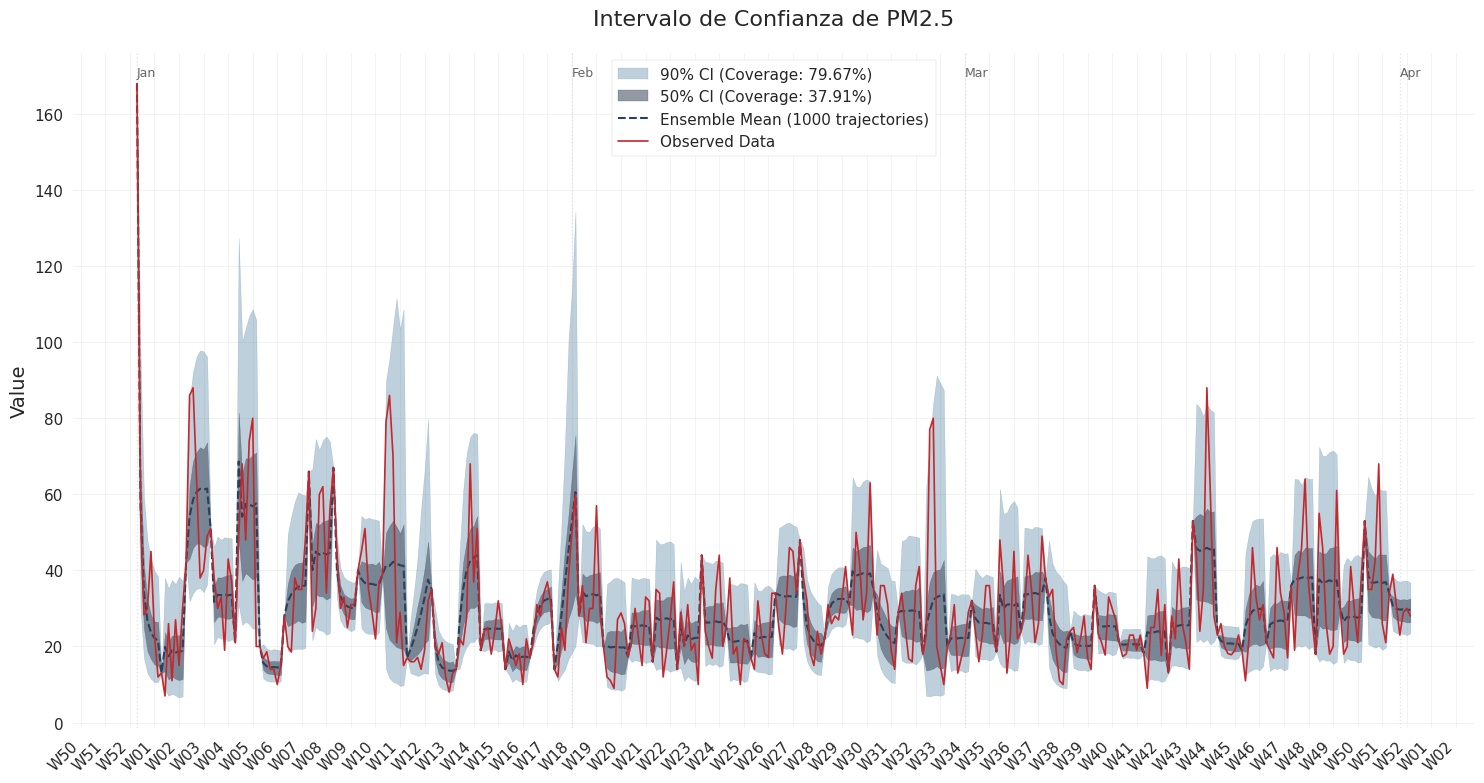

In [109]:
# Básico con fechas
model = fit_ou_regression_model(
    df_pm25_2022_smoothed, 
    'pm2.5_2022_max_6h',
    n_segments=200,
    start_date="2022-01-01",    # Fecha de inicio
    enforce_positive=True,
    log_transform=True
)

# Segmentos específicos
fig = model.plot_selected_segments(
    segment_indices=list(range(0, 52)),
    title="Intervalo de Confianza de PM2.5"
)

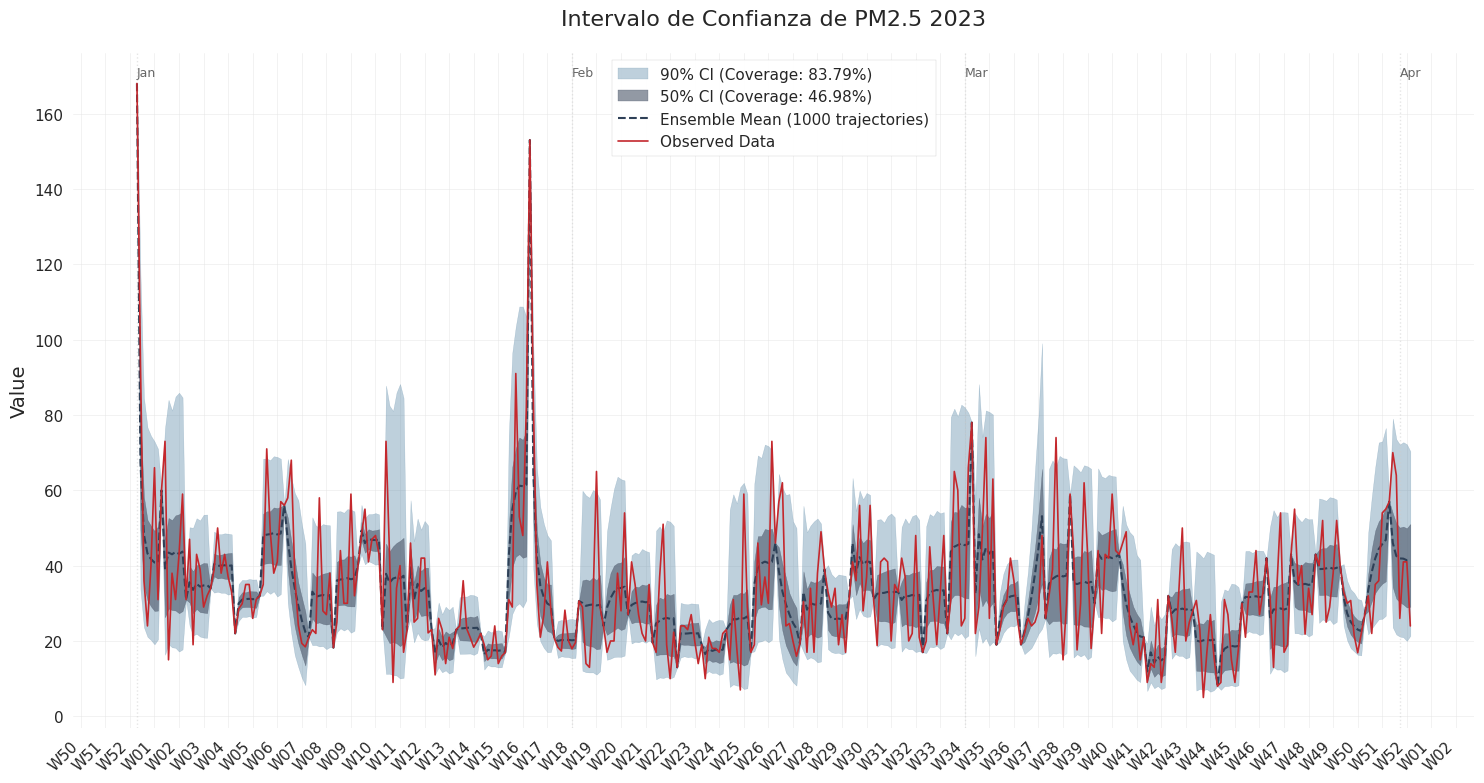

In [112]:
# Básico con fechas
model = fit_ou_regression_model(
    df_pm25_2023_smoothed, 
    'pm2.5_2023_max_6h',
    n_segments=200,
    start_date="2023-01-01",    # Fecha de inicio
    enforce_positive=True,
    log_transform=True
)

# Segmentos específicos
fig = model.plot_selected_segments(
    segment_indices=list(range(0, 52)),
    title="Intervalo de Confianza de PM2.5 2023"
)

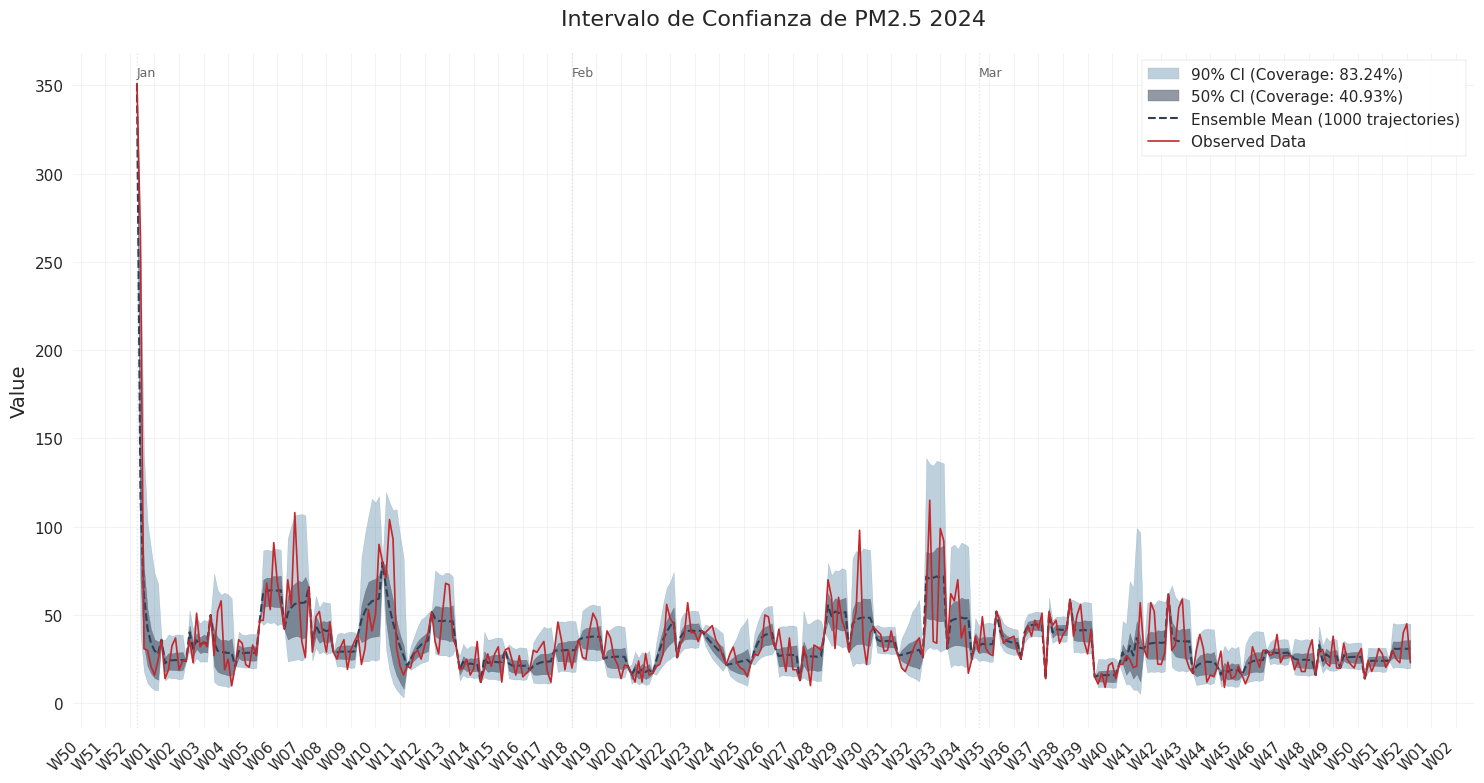

In [116]:
# Básico con fechas
model = fit_ou_regression_model(
    df_pm25_2024_smoothed, 
    'pm2.5_2024_max_6h',
    n_segments=200,
    start_date="2024-01-01",    # Fecha de inicio
    enforce_positive=True,
    log_transform=True
)

# Segmentos específicos
fig = model.plot_selected_segments(
    segment_indices=list(range(0, 52)),
    title="Intervalo de Confianza de PM2.5 2024"
)

## Generación de intervalos de confianza PM10 2022, 2023, 2024.

In [117]:
df_pm10_2022 = df_table_pm10[['hour_of_year', "pm10_2022"]]
df_pm10_2023 = df_table_pm10[['hour_of_year', "pm10_2023"]]
df_pm10_2024 = df_table_pm10[['hour_of_year', "pm10_2024"]]

imputer_pm10_2022 = imputation.TimeSeriesImputer(df_pm10_2022)
imputer_pm10_2023 = imputation.TimeSeriesImputer(df_pm10_2023)
imputer_pm10_2024 = imputation.TimeSeriesImputer(df_pm10_2024)

# Aplicar todas las estrategias a una columna específica
df_pm10_2022_imputed = imputer_pm10_2022.bootstrap_imputation_df('pm10_2022')
df_pm10_2023_imputed = imputer_pm10_2023.bootstrap_imputation_df('pm10_2023')
df_pm10_2024_imputed = imputer_pm10_2024.bootstrap_imputation_df('pm10_2024')


## Time series smoothing

In [118]:
df_pm10_2022_smoothed = smoothing.smooth_to_six_hour_windows(df_pm10_2022_imputed, index_col = "hour_of_year",
                                                             value_col = "pm10_2022", method = 'max')
df_pm10_2023_smoothed = smoothing.smooth_to_six_hour_windows(df_pm10_2023_imputed, index_col = "hour_of_year",
                                                             value_col = "pm10_2023", method = 'max')
df_pm10_2024_smoothed = smoothing.smooth_to_six_hour_windows(df_pm10_2024_imputed, index_col = "hour_of_year",
                                                             value_col = "pm10_2024", method = 'max')